# NB02 — Phylogenomic atlas

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Quantify the distribution of xoxF, mxaF, xoxJ, lanmodulin, and PQQ-cassette markers across GTDB taxonomy. Build the per-phylum / per-family rollup that supports H1 (xoxF dominance over mxaF) and previews H3 (lanmodulin clade restriction).

**Inputs**:
- `data/genome_marker_matrix.csv` — produced by NB01 (134,578 genomes with at least one marker hit, eggNOG/bakta/either columns per marker)
- `kbase_ke_pangenome.gtdb_taxonomy_r214v1` — full taxonomy for 293K genomes (Spark join)

**Outputs**:
- `data/marker_taxonomy_rollup_phylum.csv`
- `data/marker_taxonomy_rollup_family.csv`
- `data/marker_taxonomy_rollup_genus.csv`
- `data/h1_xoxF_vs_mxaF_per_phylum.csv`
- `figures/xoxF_vs_mxaF_by_phylum.png`
- `figures/cassette_completeness_distribution.png`

**Source-of-truth decisions** (from NB01 calibration, plan v3):
- `xoxF` → eggNOG K00114 (`xoxF_eggnog`) as primary; report either-source as inclusive secondary.
- `mxaF` → eggNOG K14028 (`mxaF_eggnog`).
- `xoxJ` → bakta (`xoxJ_bakta`).
- `lanM` → bakta (`lanM_bakta`).
- `pqq[A-E]` → eggNOG (`pqq*_eggnog`) for now; bakta-only hits not used until regex tightened in a future revision.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

try:
    spark = get_spark_session()
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()
print(spark.version)


4.0.1


## 1. Load marker matrix + full taxonomy

The marker matrix only contains genomes with at least one marker hit. To compute rates correctly we left-join against the full pangenome (293K genomes) so absentees are counted as zeros.

In [2]:
matrix = pd.read_csv(Path("../data/genome_marker_matrix.csv"))
print(f"Matrix rows (genomes with any hit): {len(matrix):,}")
print(f"Matrix columns: {len(matrix.columns)}")
print(matrix.columns.tolist())


Matrix rows (genomes with any hit): 134,578
Matrix columns: 28
['genome_id', 'xoxF_eggnog', 'xoxF_bakta', 'xoxF_either', 'mxaF_eggnog', 'mxaF_bakta', 'mxaF_either', 'xoxJ_eggnog', 'xoxJ_bakta', 'xoxJ_either', 'pqqA_eggnog', 'pqqA_bakta', 'pqqA_either', 'pqqB_eggnog', 'pqqB_bakta', 'pqqB_either', 'pqqC_eggnog', 'pqqC_bakta', 'pqqC_either', 'pqqD_eggnog', 'pqqD_bakta', 'pqqD_either', 'pqqE_eggnog', 'pqqE_bakta', 'pqqE_either', 'lanM_eggnog', 'lanM_bakta', 'lanM_either']


In [3]:
def _strip(df):
    df.attrs = {}
    return df

# Pull the full taxonomy (293K rows, small enough for pandas)
tax_pd = _strip(spark.table("kbase_ke_pangenome.gtdb_taxonomy_r214v1").toPandas())
print(f"Total genomes in taxonomy: {len(tax_pd):,}")

# Left-join: every genome present, marker columns 0 if missing
full = tax_pd.merge(matrix, on="genome_id", how="left")
marker_cols = [c for c in matrix.columns if c != "genome_id"]
full[marker_cols] = full[marker_cols].fillna(0).astype(int)
print(f"Full atlas rows: {len(full):,}")
print(f"Genomes with xoxF (K00114): {full['xoxF_eggnog'].sum():,}")
print(f"Genomes with mxaF (K14028): {full['mxaF_eggnog'].sum():,}")
print(f"Genomes with bakta lanmodulin: {full['lanM_bakta'].sum():,}")


Total genomes in taxonomy: 293,059


Full atlas rows: 293,059
Genomes with xoxF (K00114): 3,690
Genomes with mxaF (K14028): 195
Genomes with bakta lanmodulin: 62


## 2. Per-phylum rollup

For each phylum: count total genomes, xoxF-positive, mxaF-positive, lanmodulin-positive, full-cassette positive.

In [4]:
def cassette_complete(row):
    # full cassette = xoxF (eggNOG K00114) + xoxJ (bakta) + at least one PQQ biosynthesis (eggNOG)
    has_pqq = any(row[f"pqq{x}_eggnog"] == 1 for x in "ABCDE")
    return int((row["xoxF_eggnog"] == 1) and (row["xoxJ_bakta"] == 1) and has_pqq)

full["full_cassette"] = full.apply(cassette_complete, axis=1)

phylum_rollup = (
    full.groupby("phylum")
    .agg(
        n_genomes=("genome_id", "count"),
        n_xoxF=("xoxF_eggnog", "sum"),
        n_xoxF_either=("xoxF_either", "sum"),
        n_mxaF=("mxaF_eggnog", "sum"),
        n_xoxJ=("xoxJ_bakta", "sum"),
        n_lanM_bakta=("lanM_bakta", "sum"),
        n_full_cassette=("full_cassette", "sum"),
    )
    .sort_values("n_genomes", ascending=False)
)
phylum_rollup["xoxF_rate"] = phylum_rollup["n_xoxF"] / phylum_rollup["n_genomes"]
phylum_rollup["mxaF_rate"] = phylum_rollup["n_mxaF"] / phylum_rollup["n_genomes"]
phylum_rollup["xoxF_to_mxaF_ratio"] = phylum_rollup.apply(
    lambda r: (r["n_xoxF"] / r["n_mxaF"]) if r["n_mxaF"] > 0 else float("inf"),
    axis=1,
)
print(phylum_rollup.head(20).to_string())


                      n_genomes  n_xoxF  n_xoxF_either  n_mxaF  n_xoxJ  n_lanM_bakta  n_full_cassette  xoxF_rate  mxaF_rate  xoxF_to_mxaF_ratio
phylum                                                                                                                                         
p__Pseudomonadota        117619    2988           4358     171      61            62               17   0.025404   0.001454           17.473684
p__Bacillota              67072       9              9       4       0             0                0   0.000134   0.000060            2.250000
p__Actinomycetota         26949     106            107       0       0             0                0   0.003933   0.000000                 inf
p__Bacillota_A            24581       0              0       0       0             0                0   0.000000   0.000000                 inf
p__Bacteroidota           20615      22             22       0       0             0                0   0.001067   0.000000             

## 3. Per-family rollup (top 30 by genome count, restricted to families with any cassette presence)

In [5]:
family_rollup = (
    full.groupby(["phylum", "family"])
    .agg(
        n_genomes=("genome_id", "count"),
        n_xoxF=("xoxF_eggnog", "sum"),
        n_xoxF_either=("xoxF_either", "sum"),
        n_mxaF=("mxaF_eggnog", "sum"),
        n_xoxJ=("xoxJ_bakta", "sum"),
        n_lanM_bakta=("lanM_bakta", "sum"),
        n_full_cassette=("full_cassette", "sum"),
    )
)
family_rollup["xoxF_rate"] = family_rollup["n_xoxF"] / family_rollup["n_genomes"]

family_with_cassette = family_rollup[family_rollup["n_xoxF"] > 0].sort_values("n_xoxF", ascending=False)
print(f"Families with at least one xoxF-bearing genome: {len(family_with_cassette):,}")
print(family_with_cassette.head(30).to_string())


Families with at least one xoxF-bearing genome: 268
                                           n_genomes  n_xoxF  n_xoxF_either  n_mxaF  n_xoxJ  n_lanM_bakta  n_full_cassette  xoxF_rate
phylum             family                                                                                                            
p__Pseudomonadota  f__Pseudomonadaceae         13315     566            566       1       0             0                0   0.042508
                   f__Xanthobacteraceae          768     224            474      11       0             0                0   0.291667
                   f__Burkholderiaceae          6039     207            359       0       0             0                0   0.034277
                   f__Rhodobacteraceae          2092     204            232      15      27             0                2   0.097514
                   f__Beijerinckiaceae           508     171            255      55      18            48               10   0.336614
          

## 4. Per-genus rollup (lanmodulin-bearing genera only)

In [6]:
genus_rollup = (
    full.groupby(["phylum", "family", "genus"])
    .agg(
        n_genomes=("genome_id", "count"),
        n_xoxF=("xoxF_eggnog", "sum"),
        n_lanM_bakta=("lanM_bakta", "sum"),
        n_full_cassette=("full_cassette", "sum"),
    )
)
lanm_genera = genus_rollup[genus_rollup["n_lanM_bakta"] > 0].sort_values("n_lanM_bakta", ascending=False)
print(f"Genera with bakta-validated lanmodulin: {len(lanm_genera):,}")
print(lanm_genera.head(20).to_string())


Genera with bakta-validated lanmodulin: 4
                                                            n_genomes  n_xoxF  n_lanM_bakta  n_full_cassette
phylum            family               genus                                                                
p__Pseudomonadota f__Beijerinckiaceae  g__Methylobacterium        209     102            46                8
                  f__Acetobacteraceae  g__BOG-930                  14       1            12                0
                  f__Beijerinckiaceae  g__Methylocella              4       3             2                2
                  f__Hyphomicrobiaceae g__Hyphomicrobium_B         14      12             2                2


## 5. H1 preview — xoxF vs mxaF per phylum

Binomial test: is the per-phylum xoxF rate significantly different from the mxaF rate? We compute the rate ratio (xoxF / mxaF) and a two-sided binomial test on the joint sample (n_xoxF + n_mxaF, expected 0.5 split under H0). This is a *preview* — formal hypothesis tests with corrections are in NB03.

In [7]:
from scipy.stats import binomtest

h1_rows = []
for phy, row in phylum_rollup.iterrows():
    n_x = int(row["n_xoxF"])
    n_m = int(row["n_mxaF"])
    if (n_x + n_m) == 0:
        continue
    test = binomtest(n_x, n_x + n_m, p=0.5, alternative="two-sided")
    h1_rows.append({
        "phylum": phy,
        "n_genomes": int(row["n_genomes"]),
        "n_xoxF": n_x,
        "n_mxaF": n_m,
        "xoxF_fraction": n_x / (n_x + n_m),
        "binomial_p_two_sided": test.pvalue,
    })

h1_per_phylum = pd.DataFrame(h1_rows).sort_values("n_genomes", ascending=False)
print(h1_per_phylum.to_string(index=False))


               phylum  n_genomes  n_xoxF  n_mxaF  xoxF_fraction  binomial_p_two_sided
    p__Pseudomonadota     117619    2988     171       0.945869          0.000000e+00
         p__Bacillota      67072       9       4       0.692308          2.668457e-01
    p__Actinomycetota      26949     106       0       1.000000          2.465190e-32
      p__Bacteroidota      20615      22       0       1.000000          4.768372e-07
  p__Campylobacterota       7523      12       0       1.000000          4.882812e-04
   p__Patescibacteria       3412       2       0       1.000000          5.000000e-01
 p__Verrucomicrobiota       2440      19       5       0.791667          6.610751e-03
   p__Cyanobacteriota       2440       1       0       1.000000          1.000000e+00
     p__Chloroflexota       1596      19       0       1.000000          3.814697e-06
   p__Planctomycetota       1120       6       0       1.000000          3.125000e-02
  p__Thermoplasmatota       1116       1       0      

## 6. Save outputs

In [8]:
out_dir = Path("../data")
_strip(phylum_rollup.reset_index()).to_csv(out_dir / "marker_taxonomy_rollup_phylum.csv", index=False)
_strip(family_rollup.reset_index()).to_csv(out_dir / "marker_taxonomy_rollup_family.csv", index=False)
_strip(genus_rollup.reset_index()).to_csv(out_dir / "marker_taxonomy_rollup_genus.csv", index=False)
_strip(h1_per_phylum).to_csv(out_dir / "h1_xoxF_vs_mxaF_per_phylum.csv", index=False)
print("Wrote 4 rollup CSVs.")


Wrote 4 rollup CSVs.


## 7. Figures

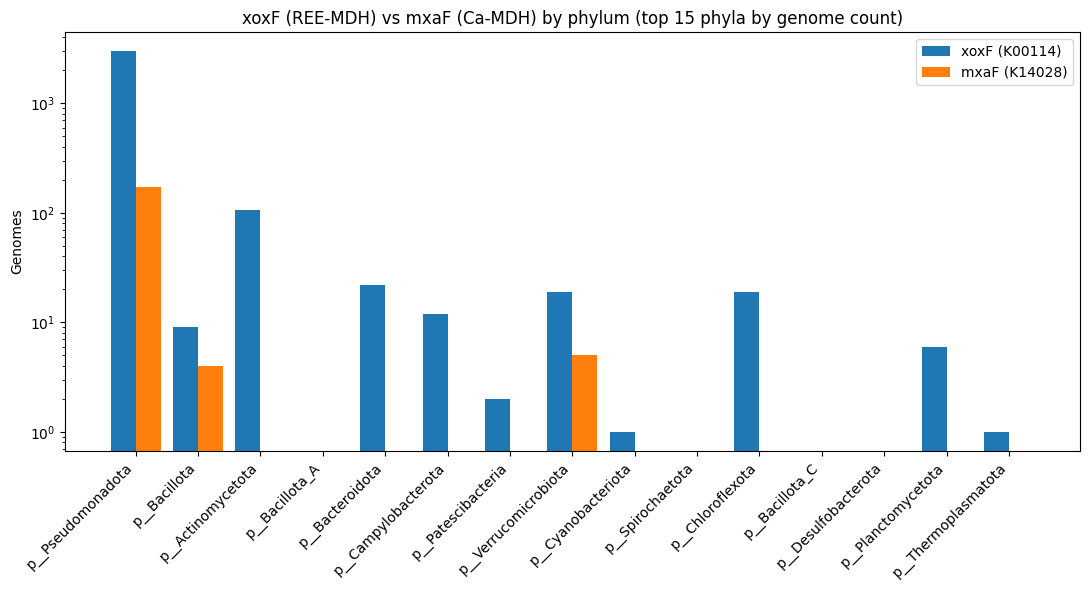

In [9]:
fig_dir = Path("../figures")
top_phyla = phylum_rollup.head(15).reset_index()
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(top_phyla))
ax.bar(x - 0.2, top_phyla["n_xoxF"], width=0.4, label="xoxF (K00114)", color="#1f77b4")
ax.bar(x + 0.2, top_phyla["n_mxaF"], width=0.4, label="mxaF (K14028)", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels(top_phyla["phylum"], rotation=45, ha="right")
ax.set_ylabel("Genomes")
ax.set_title("xoxF (REE-MDH) vs mxaF (Ca-MDH) by phylum (top 15 phyla by genome count)")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / "xoxF_vs_mxaF_by_phylum.png", dpi=150)
plt.show()


cassette_class
none             279896
PQQ_no_xoxF        9473
xoxF_only          2178
xoxF+PQQ           1488
full_cassette        17
xoxF+xoxJ             7


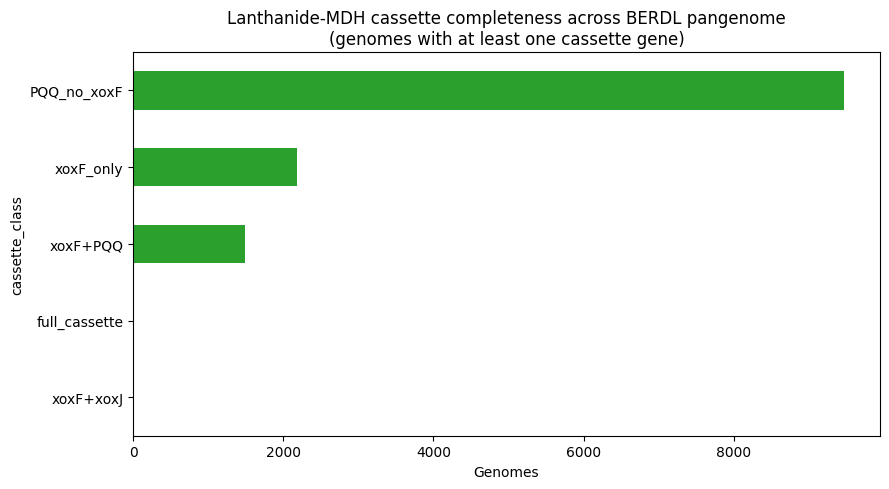

In [10]:
# Cassette-completeness distribution: how many genomes carry which fragments?
def classify_cassette(row):
    has_xoxF = row["xoxF_eggnog"] == 1
    has_xoxJ = row["xoxJ_bakta"] == 1
    has_pqq = any(row[f"pqq{x}_eggnog"] == 1 for x in "ABCDE")
    if has_xoxF and has_xoxJ and has_pqq:
        return "full_cassette"
    if has_xoxF and has_pqq:
        return "xoxF+PQQ"
    if has_xoxF and has_xoxJ:
        return "xoxF+xoxJ"
    if has_xoxF:
        return "xoxF_only"
    if has_pqq and not has_xoxF:
        return "PQQ_no_xoxF"
    return "none"

full["cassette_class"] = full.apply(classify_cassette, axis=1)
class_counts = full["cassette_class"].value_counts()
print(class_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
class_counts.drop("none", errors="ignore").plot(kind="barh", ax=ax, color="#2ca02c")
ax.invert_yaxis()
ax.set_xlabel("Genomes")
ax.set_title("Lanthanide-MDH cassette completeness across BERDL pangenome\n(genomes with at least one cassette gene)")
plt.tight_layout()
plt.savefig(fig_dir / "cassette_completeness_distribution.png", dpi=150)
plt.show()


## 8. Summary

NB02 has produced rollups at phylum / family / genus levels and a preview of H1 (xoxF vs mxaF dominance). Key findings to be formalized in NB03:
- The xoxF:mxaF ratio across the pangenome.
- Per-phylum xoxF dominance (binomial p-values).
- Cassette-completeness distribution (full / partial / xoxF-only / PQQ-no-xoxF).
- Lanmodulin clade restriction (genus-level table).

NB03 will run formal H1 statistics with phylum stratification and multiple-testing correction.